In [169]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print('libraries oke')

libraries oke


In [170]:
df = pd.read_csv('claim_data_2025.csv')

In [171]:
df.head(3)

,manage_unit_code,unit_code,claim_id,policy_id,motor_category,motor_make,motor_model,chassis_number,license_plate,system_date,incident_date,policy_effective_date,policy_expiration_date,claim_approved_date,driving_license_class,compensation_amount_lcy,car_price,business_car_flag,car_price_group,old_or_new_car_flag
0,'0001,'000,20250603063121,20240801208481,XE,JAC,HFC1341P1K5H45S1V,LJ11R6GJ1N3302183,29K04381,2025-06-03,2025-05-31,2024-08-01,2025-08-01,NaN,C,3461500.0,1.550000e+09,For business purpose,1B-2B,New
1,'035,'000,20250728564901,20241226073105,XE,THACO,THACO.68.2022.1,RN5B36SEMRN007976,81H03878,2025-07-28,2025-07-16,2024-12-30,2025-12-30,NaN,E,19600000.0,0.000000e+00,For business purpose,0-500M,Old
2,'001,'000,20250815498192,20250723206353,XE,TOYOTA,TOYOTA.17.2024.1,RL4AB3GS3R2893078,62A46368,2025-08-15,2025-08-15,2025-08-15,2026-08-15,NaN,B2,886000.0,1.102000e+09,Not for business purpose,1B-2B,Old


In [172]:
_from = df['system_date'].min()
_to = df['system_date'].max()
print('Start date of dataset is:', _from)
print('End date of dataset is:', _to)

Start date of dataset is: 2025-01-01
End date of dataset is: 2025-12-31


In [173]:
df.nunique()

manage_unit_code              53
unit_code                      1
claim_id                   84928
policy_id                  61379
motor_category                 3
motor_make                   196
motor_model                 9474
chassis_number             63553
license_plate              62405
system_date                  364
incident_date                534
policy_effective_date       1070
policy_expiration_date      1070
claim_approved_date          450
driving_license_class         25
compensation_amount_lcy    40002
car_price                   4790
business_car_flag              2
car_price_group                4
old_or_new_car_flag            3
dtype: int64

In [174]:
print('before cleaning NaN/duplicated: \n')
print('rows:', df.shape[0])
print('columns:', df.shape[1])

before cleaning NaN/duplicated: 

rows: 85072
columns: 20


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85072 entries, 0 to 85071
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   manage_unit_code         85072 non-null  object 
 1   unit_code                85072 non-null  object 
 2   claim_id                 85072 non-null  int64  
 3   policy_id                85072 non-null  int64  
 4   motor_category           85072 non-null  object 
 5   motor_make               85072 non-null  object 
 6   motor_model              85072 non-null  object 
 7   chassis_number           84702 non-null  object 
 8   license_plate            85072 non-null  object 
 9   system_date              85072 non-null  object 
 10  incident_date            85072 non-null  object 
 11  policy_effective_date    84829 non-null  object 
 12  policy_expiration_date   84829 non-null  object 
 13  claim_approved_date      83256 non-null  object 
 14  driving_license_class 

In [176]:
dupe = df.duplicated().sum()
print('duplicated entries:', dupe)

duplicated entries: 45


In [177]:
missing = df.isna().sum()
print('Missing values: \n')
print(missing[missing>0])

Missing values: 

chassis_number             370
policy_effective_date      243
policy_expiration_date     243
claim_approved_date       1816
driving_license_class        8
car_price                  555
business_car_flag          555
dtype: int64


In [178]:
df['driving_license_class'] = df['driving_license_class'].fillna('Unknown')
df['chassis_number'] = df['chassis_number'].fillna('Unknown')
df['business_car_flag'] = df['business_car_flag'].fillna('Unknown')
df['car_price'] = df['business_car_flag'].fillna(0)
df['claim_approved_date'] = df['claim_approved_date'].fillna('')
df['policy_effective_date'] = df['policy_effective_date'].fillna('')
df['policy_expiration_date'] = df['policy_expiration_date'].fillna('')

In [179]:
missing_after = df.isna().sum()
print('Missing values: \n')
print(missing_after[missing_after>0])

Missing values: 

Series([], dtype: int64)


In [180]:
print('after cleaning NaN/duplicated: \n')
print('rows:', df.shape[0])
print('columns:', df.shape[1])

after cleaning NaN/duplicated: 

rows: 85072
columns: 20


In [181]:
conditions = [
    (df['motor_category'] == 'XE'),
    (df['motor_category'] == '2B'),
    (df['motor_category'] == '2BL')
]
choices = ['Car', 'Motorbike','Retail motorbike']

df['motor_category_label'] = np.select(conditions, choices, default='Car')

In [182]:
df['manage_unit_code'] = df['manage_unit_code'].str.replace("'","")
df['unit_code'] = df['unit_code'].str.replace("'","")

In [183]:
df_by_motor_category = df.groupby(by = 'motor_category_label').agg(total_claim = ('claim_id','count')).reset_index()
# print(df_by_motor_category)

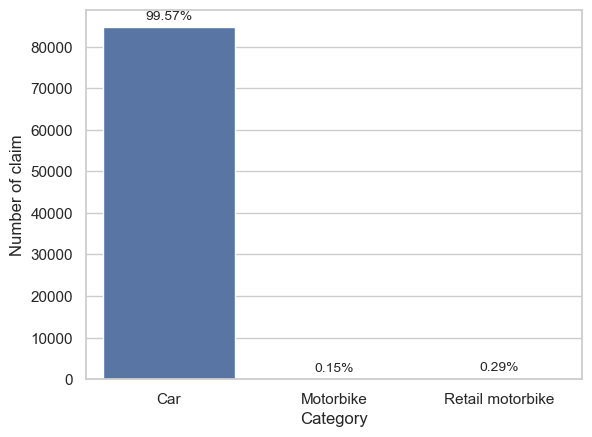

Most of claim document from Car policy,it about 84702 document (99.57 %)


In [184]:
#variable:
most_claim_value = df_by_motor_category[df_by_motor_category['total_claim'] == df_by_motor_category['total_claim'].max()]['total_claim'].values[0]
most_claim = df_by_motor_category[df_by_motor_category['total_claim'] == df_by_motor_category['total_claim'].max()]['motor_category_label'].values[0]
most_claim_rate = round(most_claim_value/df.shape[0] * 100,2)

#chart:
sns.barplot(data=df_by_motor_category, x='motor_category_label',y='total_claim')
plt.ylabel('Number of claim')
plt.xlabel('Category')

total_rows = df.shape[0]
ax = plt.gca()  
for p in ax.patches:
    height = p.get_height()
    rate = round(height / total_rows * 100, 2)
    ax.annotate(f'{rate}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom',
                fontsize=10, xytext=(0,3), textcoords='offset points')
plt.show()

#comment
print(f'Most of claim document from {most_claim} policy,it about {most_claim_value} document ({most_claim_rate} %)')

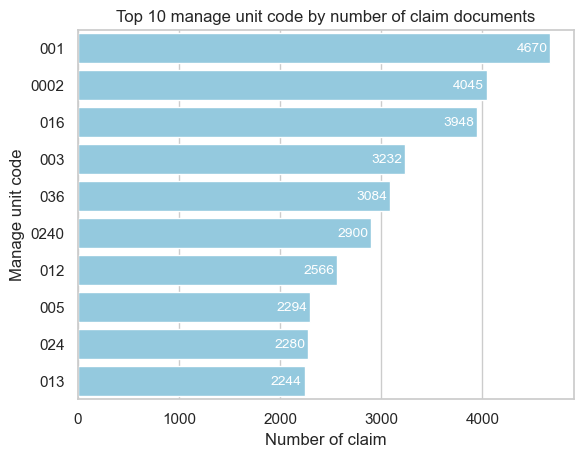

In [185]:
df_manage_unit_code = df.groupby(by='manage_unit_code').agg(
    total_claim=('claim_id','count')
).reset_index().sort_values(by='total_claim', ascending=False).reset_index(drop=True)

df_manage_unit_code_top10 = df_manage_unit_code.head(10)

# Vẽ barplot
sns.barplot(data=df_manage_unit_code_top10, y='manage_unit_code', x='total_claim',color='skyblue')

plt.xlabel('Number of claim')
plt.ylabel('Manage unit code')
plt.title('Top 10 manage unit code by number of claim documents')

ax = plt.gca()
for p in ax.patches:
    width = p.get_width()  # Vì x-axis là total_claim nên width là giá trị
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2), 
                ha='right', va='center', color='white',
                fontsize=10,
                xytext=(-2,0), textcoords='offset points')  

plt.show()

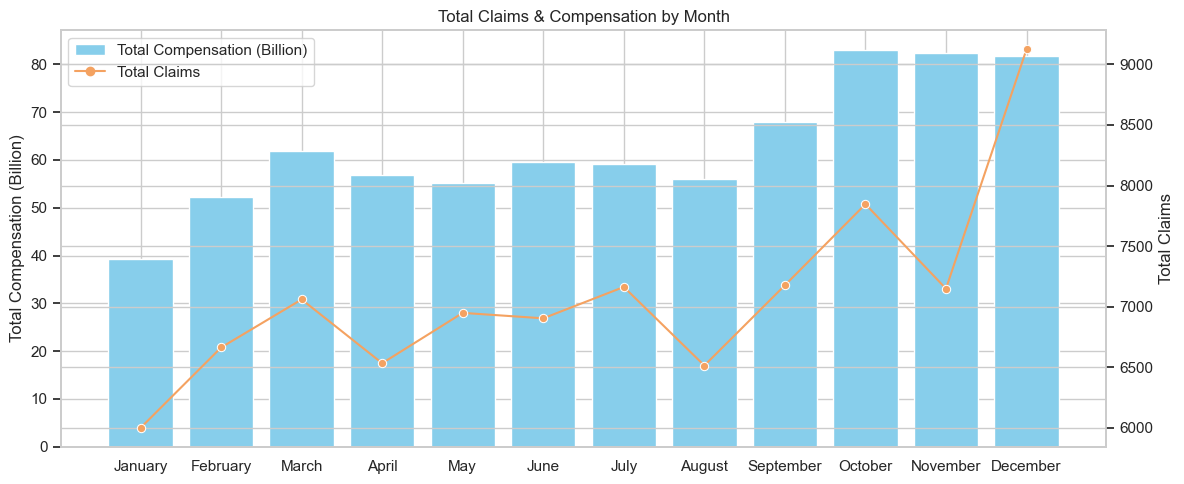

Observation: The number of claims starts increasing from September, likely due to the rainy and stormy season, causing damages to customers vehicles.


In [186]:
df['system_date'] = pd.to_datetime(df['system_date'])

df_monthly = (
    df.groupby(df['system_date'].dt.to_period('M')) 
      .agg(total_claim=('claim_id','count'),total_claim_amount=('compensation_amount_lcy','sum'))
      .reset_index()
      .sort_values(by='total_claim', ascending=False)
)

df_monthly['total_claim_amount_billion'] = df_monthly['total_claim_amount'] / 1e9

df_monthly['system_date_dt'] = df_monthly['system_date'].dt.to_timestamp()

# Tạo cột month_name bằng tiếng Anh
df_monthly['month_name'] = df_monthly['system_date_dt'].dt.month_name()

# Đặt thứ tự tháng
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df_monthly['month_name'] = pd.Categorical(df_monthly['month_name'], categories=month_order, ordered=True)


df_monthly = df_monthly.sort_values('month_name')

sns.set(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12,5))
# số tiền
bars = ax1.bar(
    df_monthly['month_name'],
    df_monthly['total_claim_amount_billion'],
    color='skyblue',
    label='Total Compensation (Billion)'
)
ax1.set_ylabel('Total Compensation (Billion)')
#số vụ
ax2 = ax1.twinx()
line = sns.lineplot(
    data=df_monthly,
    x='month_name',
    y='total_claim',
    marker='o',
    ax=ax2,
    color='#F4A261',
    label='Total Claims',
    legend=False
)
ax2.set_ylabel('Total Claims')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='skyblue', label='Total Compensation (Billion)'),
    Line2D([0], [0], color='#F4A261', marker='o', label='Total Claims')
]

ax1.legend(handles=legend_elements, loc='upper left')

# Format
plt.xlabel('Month')
plt.title('Total Claims & Compensation by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#comment:
print('Observation: The number of claims starts increasing from September, likely due to the rainy and stormy season, \
causing damages to customers vehicles.')

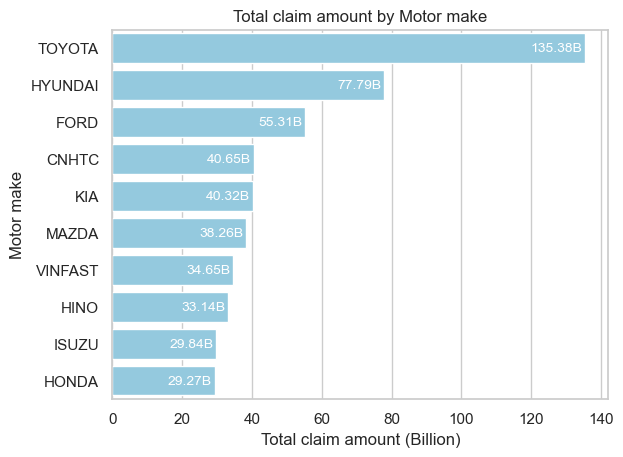

For high-severity vehicle segments such as Toyota, a combination of premium adjustment,
mandatory cross-selling, and stricter underwriting is recommended to mitigate financial risk and improve portfolio profitability.


In [187]:
df_make = df.groupby('motor_make',as_index=False).agg(
    total_claim_amount=('compensation_amount_lcy','sum')
)
df_make.sort_values(by='total_claim_amount',ascending=False,inplace=True)

df_make['total_claim_amount_billion'] = round(df_make['total_claim_amount']/1e9,2)

df_make = df_make.head(10)
sns.barplot(
    data=df_make.sort_values('total_claim_amount_billion', ascending=False),
    x='total_claim_amount_billion',
    y='motor_make',
    color='skyblue'
)

plt.xlabel('Average Claim (Billion)')

ax = plt.gca()
for p in ax.patches:
    width = p.get_width() 
    ax.annotate(f'{width}B', 
                (width, p.get_y() + p.get_height() / 2), 
                ha='right', va='center', color='white',
                fontsize=10,
                xytext=(-2,0), textcoords='offset points')  
    
plt.title('Total claim amount by Motor make')
plt.xlabel('Total claim amount (Billion)')
plt.ylabel('Motor make')

plt.show()
#comment:
print('For high-severity vehicle segments such as Toyota, a combination of premium adjustment,\n\
mandatory cross-selling, and stricter underwriting is recommended to mitigate financial risk and improve portfolio profitability.')

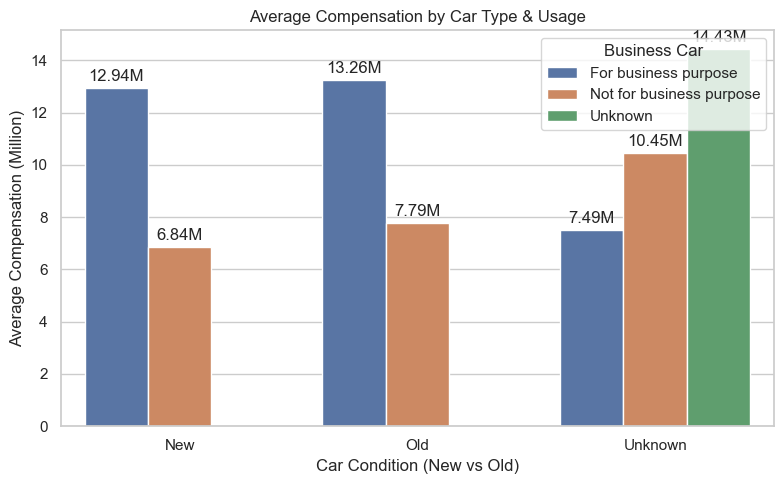

In [188]:
# Tính avg
df_plot = df.groupby(
    ['old_or_new_car_flag', 'business_car_flag'],
    as_index=False
).agg(
    avg_compensation=('compensation_amount_lcy', 'mean')
)

df_plot['avg_compensation_million'] = df_plot['avg_compensation'] / 1e6

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df_plot,
    x='old_or_new_car_flag',
    y='avg_compensation_million',
    hue='business_car_flag'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2fM',   # format label
        padding=3
    )

plt.xlabel('Car Condition (New vs Old)')
plt.ylabel('Average Compensation (Million)')
plt.title('Average Compensation by Car Type & Usage')

plt.legend(title='Business Car')
plt.tight_layout()
plt.show()

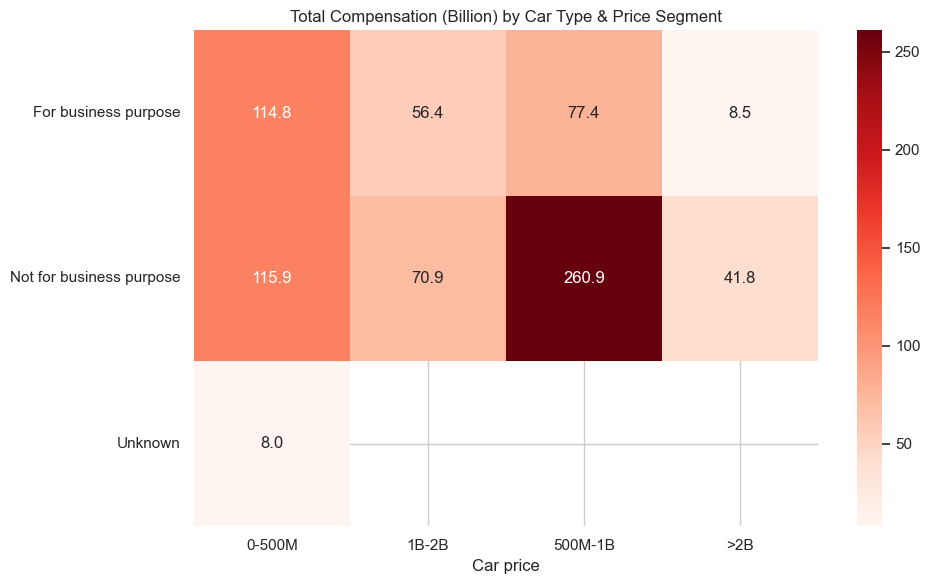

Despite their high asset value, luxury vehicles (>2B VND) used for commercial purposes demonstrate relatively 
low claim exposure. This suggests a well-managed risk segment and highlights an opportunity to strategically grow insurance 
penetration through targeted cross-selling in premium sectors such as hospitality and high-end tourism.


In [189]:
# Pivot table
pivot = df.pivot_table(
    index='business_car_flag',
    columns='car_price_group',
    values='compensation_amount_lcy',
    aggfunc='sum'
)

# Convert sang tỷ cho dễ nhìn
pivot = pivot / 1e9

# Plot
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Total Compensation (Billion) by Car Type & Price Segment')
plt.xlabel('Car price')
plt.ylabel('')

plt.tight_layout()
plt.show()

#comment:
print('Despite their high asset value, luxury vehicles (>2B VND) used for commercial purposes demonstrate relatively \n\
low claim exposure. This suggests a well-managed risk segment and highlights an opportunity to strategically grow insurance \n\
penetration through targeted cross-selling in premium sectors such as hospitality and high-end tourism.')

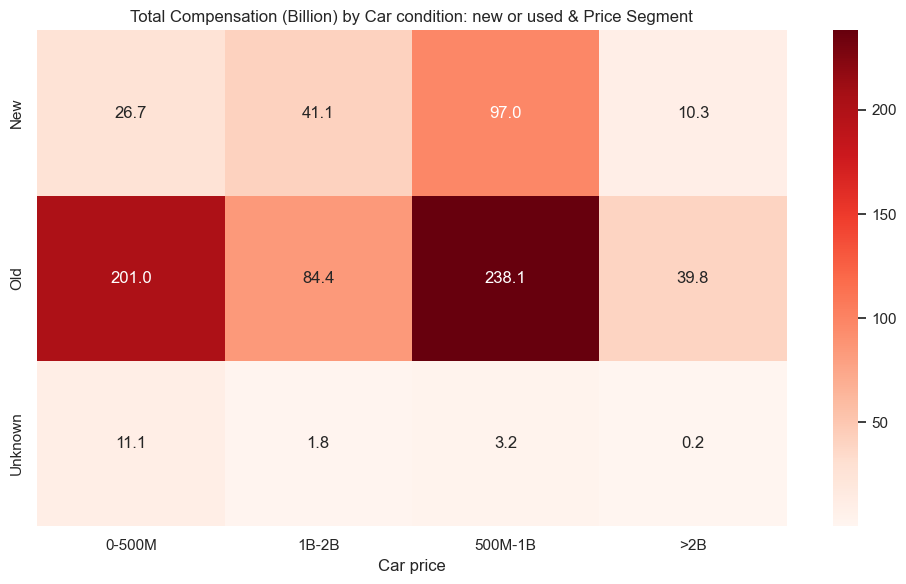

Despite their high asset value, luxury vehicles (>2B VND) used for commercial purposes demonstrate relatively 
low claim exposure. This suggests a well-managed risk segment and highlights an opportunity to strategically grow insurance 
penetration through targeted cross-selling in premium sectors such as hospitality and high-end tourism.


In [190]:
# Pivot table
pivot = df.pivot_table(
    index='old_or_new_car_flag',
    columns='car_price_group',
    values='compensation_amount_lcy',
    aggfunc='sum'
)

pivot = pivot / 1e9

# Plot
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Total Compensation (Billion) by Car condition: new or used & Price Segment')
plt.xlabel('Car price')
plt.ylabel('')

plt.tight_layout()
plt.show()

#comment:
print('Despite their high asset value, luxury vehicles (>2B VND) used for commercial purposes demonstrate relatively \n\
low claim exposure. This suggests a well-managed risk segment and highlights an opportunity to strategically grow insurance \n\
penetration through targeted cross-selling in premium sectors such as hospitality and high-end tourism.')